In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept, # this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # a funky session
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

In [23]:
%load_ext autoreload
%autoreload
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import extract_pa_across_sesh
from JR_test_scripts.trial_heading_angle import initial_heading_angle
from behave_analysis.process.process import Process

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# fixed vars
%autoreload
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview\behavior"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr_excl_prox_15cm'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm','all_angles_fr_excl_stationary'

In [4]:
all_names = []    
for sesh in experiments_objects:    
    name = sesh.nick_name + '_' + sesh.experiment_date
    all_names.append(name)

In [50]:
'''load escape and homing attributes'''
exclude_south = True
se = {}
head = {}
head_corr = {}
h_se = {}
h_head = {}
for c in conditions:
    se[c] = np.empty((len(experiments_objects)))
    head[c] = np.zeros((len(experiments_objects),3))
    head_corr[c] = np.zeros((len(experiments_objects),3))
    h_se[c] = np.empty((len(experiments_objects)))
    h_head[c] = np.empty((len(experiments_objects),3))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = Process(sesh).load_session()
    
    # load tracking
    track_path = os.path.join(session.base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)

    # escape
    onsets = session.__dict__["audio"].onset_frames
    stimulus_durations = session.__dict__["audio"].stimulus_durations

    if isinstance(onsets[0],np.ndarray):
        onsets = [on[0] for on in onsets]
        stimulus_durations = [st[0] for st in stimulus_durations]
    
    # load tracking
    esc_path = os.path.join(session.base_path,session.processed_path,'escapes',r"escapes_obj.pkl")
    with open(esc_path, "rb") as dill_file:
        esc = pickle.load(dill_file)

    offsets = [int(on + (st*40)) for on,st in zip(onsets,stimulus_durations)]
    heading, heading_correct = initial_heading_angle(session, onsets, offsets, esc.head_orientation["avg_hdir"], esc.escape_condition, tracking_data)
    
    # spatial efficiency
    for c in conditions:
        se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))
        head[c][s,:] = heading[c]
        head_corr[c][s,:] = heading_correct[c]
    
    # load homings
    h_path = os.path.join(session.base_path,session.processed_path,'homings',r"homings_obj.pkl")
    with open(h_path, "rb") as dill_file:
        h = pickle.load(dill_file)

    heading, heading_correct = initial_heading_angle(session, h.onset_frames, h.offset_frames, h.homing_angles_dic["avg_hdir"], h.homing_condition, tracking_data, exclude_south)
    
    # spatial efficiency
    for c in conditions:
        h_se[c][s] = np.mean([x for x, y in zip(h.spatial_efficiency,h.homing_condition) if y == c])
        h_head[c][s,:] = heading[c]

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_23636\3172219543.py:42: RuntimeWarning: Mean of empty slice
  se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))


real stat: 0.20281084656084658
0.029


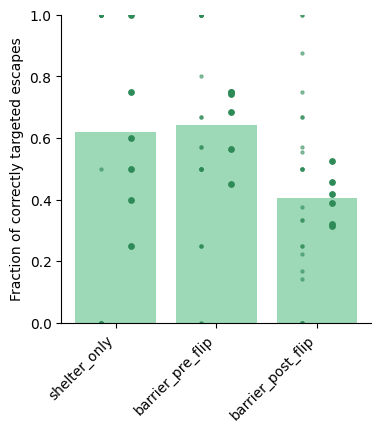

In [48]:
"""Plot the fraction of correct heading escapes in each condition"""
# TODO separate by halves?

head_use = head
# head_use = head_corr # filter out escapes that don't start with mouse facing puff

good_escapes = [np.pi/4,3*(np.pi/4)]

fig, axs = plt.subplots(1,1, figsize = (4,4))

fract_correct_esc = np.zeros((len(conditions),len(head_use['shelter_only'][:,1])))
non_zero_shelt = np.sum(head_use['shelter_only'], axis = 1) > 0
fract_correct_esc[0,non_zero_shelt] = head_use['shelter_only'][non_zero_shelt,1]/np.sum(head_use['shelter_only'][non_zero_shelt,:], axis = 1)

non_zero_bar = np.sum(head_use['barrier_pre_flip'], axis = 1) > 0
fract_correct_esc[1,non_zero_bar] = head_use['barrier_pre_flip'][non_zero_bar,0]/np.sum(head_use['barrier_pre_flip'][non_zero_bar,:], axis = 1)

non_zero_flip = np.sum(head_use['barrier_post_flip'], axis = 1) > 0
fract_correct_esc[2,non_zero_flip] = head_use['barrier_post_flip'][non_zero_flip,2]/np.sum(head_use['barrier_post_flip'][non_zero_flip,:], axis = 1)

mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_fract = np.zeros((len(unique_mouse),np.shape(fract_correct_esc)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_fract[m_idx,:] = np.mean(fract_correct_esc[:,this_mouse], axis=1)

axs.bar(conditions,np.nanmean(fract_correct_esc, axis = 1),color = 'mediumseagreen',alpha = .5)
for i, c in enumerate(conditions):
    axs.scatter((np.ones(len(fract_correct_esc[i,:]))*i)-.15,fract_correct_esc[i,:],s = 5,c = 'seagreen', alpha = .5)
    axs.scatter((np.ones(len(mean_fract[:,i]))*i)+.15,mean_fract[:,i].T,s = 15,c = 'seagreen')

axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(conditions,rotation = 45, ha="right")
axs.set_ylim([0,1])
axs.set_ylabel('Fraction of correctly targeted escapes')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

good = np.hstack((fract_correct_esc[:,:7],fract_correct_esc[:,8:])) # remove stupid nan case
d1 = good[1,:]
d2 = good[2,:]
real_stat = np.abs(np.mean(d1)-np.mean(d2))
print('real stat: ' + str(real_stat))
d = np.hstack((d1,d2))
shuffled = np.zeros(1000)
for j in np.arange(1000):
    idx = np.random.uniform(low = 0,high = 1, size =len(d))
    d_sort = d[np.argsort(idx)]
    shuffled[j] = np.abs(np.mean(d_sort[:len(d1)]) - np.mean(d_sort[len(d1):]))
print(np.sum(shuffled > real_stat)/1000)

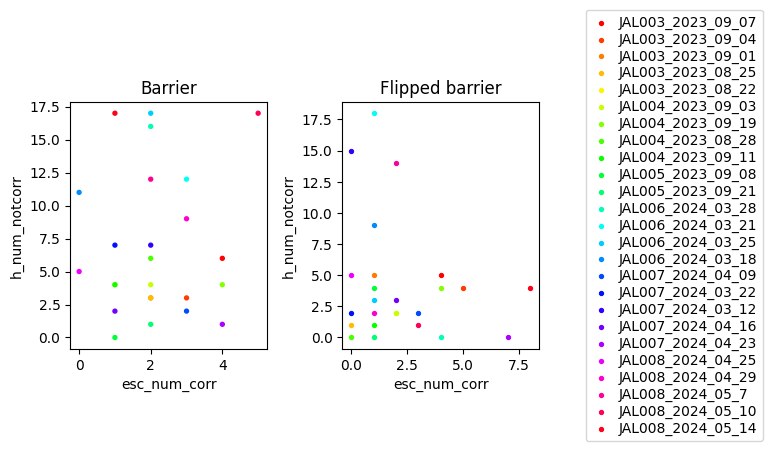

In [47]:
"""Escape correct targeting vs fraction of learning homings"""
%matplotlib inline
fig, axs = plt.subplots(1,2, figsize = (8,4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))

compare = ['esc_num_corr','h_num_notcorr']
# 'esc_se','esc_fract_corr', 'esc_num_corr'
# 'h_num_corr', 'h_fract_corr', h_num_notcorr', 'h_fract_notcorr'

if compare[0] == 'esc_se':
    x1 = se['barrier_pre_flip']
    x2 = se['barrier_post_flip']
elif compare[0] == 'esc_num_corr':
    x1 = head['barrier_pre_flip'][:,0]
    x2 = head['barrier_post_flip'][:,2]
elif compare[0] == 'esc_fract_corr':
    x1 = head['barrier_pre_flip'][:,0]/np.sum(head['barrier_pre_flip'], axis = 1)
    x2 = head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1)

if compare[1] == 'h_num_corr':
    y1 = h_head['barrier_pre_flip'][:,0]
    y2 = h_head['barrier_post_flip'][:,2]
elif compare[1] == 'h_fract_corr':
    y1 = h_head['barrier_pre_flip'][:,0]/np.sum(h_head['barrier_pre_flip'], axis = 1)
    y2 = h_head['barrier_post_flip'][:,2]/np.sum(h_head['barrier_post_flip'], axis = 1)
if compare[1] == 'h_num_notcorr':
    y1 = h_head['barrier_pre_flip'][:,1]
    y2 = h_head['barrier_post_flip'][:,0]
elif compare[1] == 'h_fract_notcorr':
    y1 = h_head['barrier_pre_flip'][:,1]/np.sum(h_head['barrier_pre_flip'], axis = 1)
    y2 = h_head['barrier_post_flip'][:,0]/np.sum(h_head['barrier_post_flip'], axis = 1)

# barrier_pre_flip
axs[0].scatter(x1,y1,s=8,c=colorz)
axs[0].set_xlabel(compare[0])
axs[0].set_ylabel(compare[1])
axs[0].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(x2,y2,colorz):
    line = axs[1].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[1].set_xlabel(compare[0])
axs[1].set_ylabel(compare[1])
axs[1].set_title('Flipped barrier')

axs[1].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
# plt.savefig(save_path+'/'+str(compare[0] + '_' + compare[1] + settings+'.png'))

Compare to prediction accuracy

In [51]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

Compare to spatial efficiency in escape


C:\Users\Jasmine\AppData\Local\Temp\ipykernel_23636\1308756922.py:16: RuntimeWarning: invalid value encountered in divide
  x2 = head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1)


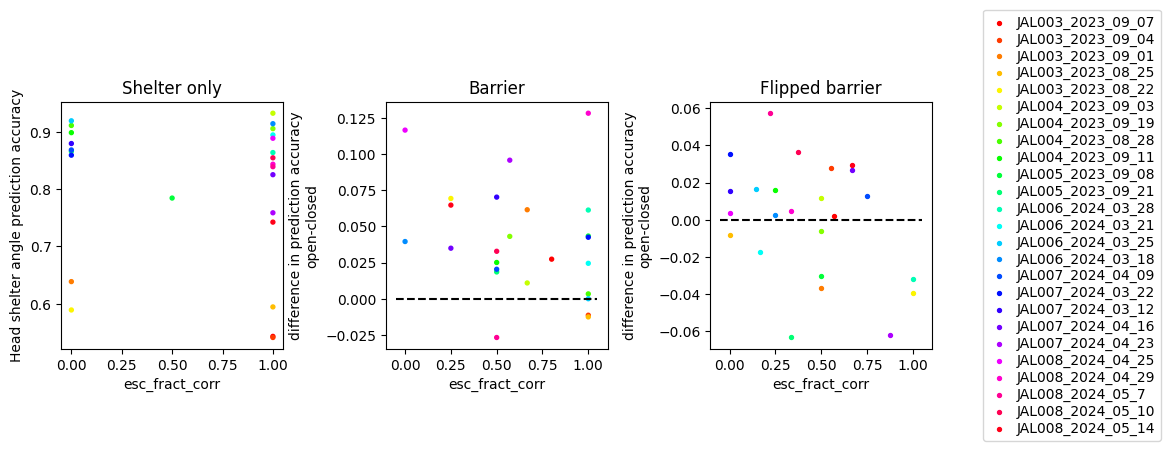

In [53]:
"""Compare escape to prediction accuracy"""
compare = ['esc_fract_corr','pa']
# 'esc_se','esc_fract_corr', 'esc_num_corr'

if compare[0] == 'esc_se':
    x0 = se['shelter_only']
    x1 = se['barrier_pre_flip']
    x2 = se['barrier_post_flip']
elif compare[0] == 'esc_num_corr':
    x0 = head['shelter_only'][:,1]
    x1 = head['barrier_pre_flip'][:,0]
    x2 = head['barrier_post_flip'][:,2]
elif compare[0] == 'esc_fract_corr':
    x0 = head['shelter_only'][:,1]/np.sum(head['shelter_only'], axis = 1)
    x1 = head['barrier_pre_flip'][:,0]/np.sum(head['barrier_pre_flip'], axis = 1)
    x2 = head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1)

if compare[1] == 'pa':
    y0 = pa['hsa'][:,0]
    y1 = pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1]
    y2 = pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2]

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(x0,y0,s=8,c=colorz)
axs[0].set_xlabel(compare[0])
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')

# barrier_pre_flip
axs[1].scatter(x1,y1,s=8,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel(compare[0])
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(x2,y2,colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel(compare[0])
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped barrier')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
# plt.savefig(save_path+'/'+str(compare[0] + '_' + compare[1] + settings+'.png'))

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_23636\1902115782.py:4: RuntimeWarning: invalid value encountered in divide
  x2 = head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1)


[Text(0, 0, 'open > closed in Barrier'),
 Text(1, 0, 'open < closed in Barrier'),
 Text(2, 0, 'open > closed in Flipped'),
 Text(3, 0, 'open < closed in Flipped')]

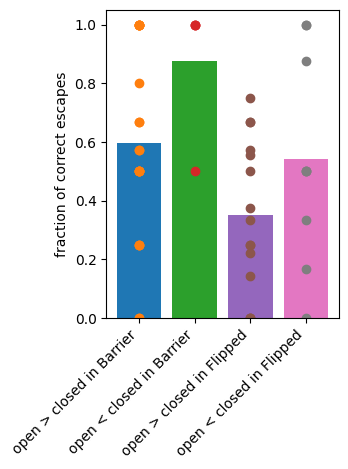

In [64]:
fig, axs = plt.subplots(1,1,figsize = (3,4))

x1 = head['barrier_pre_flip'][:,0]/np.sum(head['barrier_pre_flip'], axis = 1)
x2 = head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1)

y1 = pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1]
y2 = pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2]

axs.bar(0,np.nanmean(x1[y1>0]))
axs.scatter(np.zeros(len(x1[y1>0])),x1[y1>0])
axs.bar(1,np.nanmean(x1[y1<0]))
axs.scatter(np.ones(len(x1[y1<0])),x1[y1<0])
axs.bar(2,np.nanmean(x2[y2>0]))
axs.scatter(np.ones(len(x2[y2>0]))*2,x2[y2>0])
axs.bar(3,np.nanmean(x2[y2<0]))
axs.scatter(np.ones(len(x2[y2<0]))*3,x2[y2<0])

axs.set_ylabel('fraction of correct escapes')
axs.set_xticks(np.arange(4))
axs.set_xticklabels(['open > closed in Barrier', 'open < closed in Barrier', 'open > closed in Flipped', 'open < closed in Flipped'], rotation = 45, ha ='right')

Compare prediction accuracy to homings
- spatial efficiency
- number of homing (correct to target)
- fraction of homings (correct to target)

In [ ]:
"""Compare homings to prediction accuracy"""
compare = ['esc_num_corr','pa']
# 'h_num_corr', 'h_fract_corr', h_num_notcorr', 'h_fract_notcorr', 'h_se'

if compare[1] == 'h_num_corr':
    x0 = h_head['shelter_only'][:,1]
    x1 = h_head['barrier_pre_flip'][:,0]
    x2 = h_head['barrier_post_flip'][:,2]
elif compare[1] == 'h_fract_corr':
    x0 = h_head['shelter_only'][:,1]/np.sum(head['shelter_only'], axis = 1)
    x1 = h_head['barrier_pre_flip'][:,0]/np.sum(h_head['barrier_pre_flip'], axis = 1)
    x2 = h_head['barrier_post_flip'][:,2]/np.sum(h_head['barrier_post_flip'], axis = 1)
if compare[1] == 'h_num_notcorr':
    x0 = h_head['shelter_only'][:,1]
    x1 = h_head['barrier_pre_flip'][:,1]
    x2 = h_head['barrier_post_flip'][:,0]
elif compare[1] == 'h_fract_notcorr':
    x0 = h_head['shelter_only'][:,1]/np.sum(h_head['shelter_only'], axis = 1)
    x1 = h_head['barrier_pre_flip'][:,1]/np.sum(h_head['barrier_pre_flip'], axis = 1)
    x2 = h_head['barrier_post_flip'][:,0]/np.sum(h_head['barrier_post_flip'], axis = 1)
elif compare[1] == 'h_se':
    x0 = h_se['shelter_only']
    x1 = h_se['barrier_pre_flip']
    x2 = h_se['barrier_post_flip']

if compare[1] == 'pa':
    y0 = pa['hsa'][:,0]
    y1 = pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1]
    y2 = pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2]

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(x0,y0,s=8,c=colorz)
axs[0].set_xlabel('spatial efficiency')
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')

# barrier_pre_flip
axs[1].scatter(x1,y1,s=8,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel('spatial efficiency')
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(x2,y2,colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel('spatial efficiency')
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped barrier')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
# plt.savefig(save_path+'/'+str(compare[0] + '_' + compare[1] + settings+'.png'))